# Unit Test: Circular Supercell Model

Each scenario contains **one supercell** so the result can be visually inspected by eye.

### Three scenarios
| Scenario | Obstacle? | Sensitivity pts? | Purpose |
|---|---|---|---|
| S1 | No | No | Baseline: free (θ, L) choice |
| S2 | Yes (between BASE and circle) | No | Route must detour around obstacle |
| S3 | Yes | Yes (2 pts) | Full model: obstacle + mandatory waypoints |

After each scenario the **global optimality proof** cell enumerates *every* (θ, L) combination,
computes its route distance, and confirms the optimizer's answer matches the minimum.

## Cell 1: Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass, field
from typing import List, Optional, Tuple
from itertools import permutations, combinations, product as iproduct
from math import cos, sin, radians, sqrt

np.set_printoptions(precision=3, suppress=True)
print('Imports OK')

Imports OK


## Cell 2: Geometry Utilities

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# GEOMETRY UTILITIES
# ─────────────────────────────────────────────────────────────────────────────

def uvec(angle: float) -> np.ndarray:
    """Unit vector at given angle (radians)."""
    return np.array([cos(angle), sin(angle)])


def cross2d(v: np.ndarray, w: np.ndarray) -> float:
    """2D cross product of vectors v and w."""
    return float(v[0] * w[1] - v[1] * w[0])


def ensure_ccw(verts: List[np.ndarray]) -> List[np.ndarray]:
    """Return vertices in counter-clockwise order."""
    pts = [np.asarray(v, dtype=float) for v in verts]
    n = len(pts)
    area2 = 0.0
    for i in range(n):
        j = (i + 1) % n
        area2 += pts[i][0] * pts[j][1]
        area2 -= pts[j][0] * pts[i][1]
    if area2 < 0:
        pts = pts[::-1]
    return pts


def segments_intersect_proper(p1, p2, p3, p4) -> bool:
    """True if segment p1-p2 properly intersects segment p3-p4."""
    EPS = 1e-9
    d1 = p2 - p1
    d2 = p4 - p3
    denom = cross2d(d1, d2)
    if abs(denom) < EPS:
        return False
    diff = p3 - p1
    t = cross2d(diff, d2) / denom
    u = cross2d(diff, d1) / denom
    return (EPS < t < 1.0 - EPS) and (EPS < u < 1.0 - EPS)


def point_in_convex_polygon(pt, verts) -> bool:
    """True if pt is strictly inside the CCW convex polygon."""
    EPS = 1e-9
    n = len(verts)
    for i in range(n):
        edge = verts[(i + 1) % n] - verts[i]
        to_pt = pt - verts[i]
        if cross2d(edge, to_pt) <= EPS:
            return False
    return True


def segment_blocked_by_polygon(p1, p2, verts) -> bool:
    """True if segment p1-p2 passes through the interior of the convex polygon."""
    n = len(verts)
    for i in range(n):
        j = (i + 1) % n
        if segments_intersect_proper(p1, p2, verts[i], verts[j]):
            return True
    mid = 0.5 * (p1 + p2)
    if point_in_convex_polygon(mid, verts):
        return True
    return False


def path_length(waypoints) -> float:
    """Total Euclidean length of a sequence of waypoints."""
    total = 0.0
    for i in range(len(waypoints) - 1):
        total += np.linalg.norm(waypoints[i + 1] - waypoints[i])
    return total


def obstacle_free_path(start, end, polygon_verts):
    """
    Shortest obstacle-free path from start to end around a single convex polygon.
    Returns [start, ..., end] as a list of np.ndarray waypoints.
    """
    start = np.asarray(start, dtype=float)
    end   = np.asarray(end,   dtype=float)
    verts = [np.asarray(v, dtype=float) for v in polygon_verts]

    def is_clear(a, b):
        return not segment_blocked_by_polygon(a, b, verts)

    if is_clear(start, end):
        return [start, end]

    n = len(verts)
    best_path = None
    best_dist = float('inf')

    for v in verts:
        if is_clear(start, v) and is_clear(v, end):
            d = np.linalg.norm(v - start) + np.linalg.norm(end - v)
            if d < best_dist:
                best_dist = d
                best_path = [start, v, end]

    for start_idx in range(n):
        for length in range(1, n):
            for arc in [
                [verts[(start_idx + k) % n] for k in range(length + 1)],
                [verts[(start_idx - k) % n] for k in range(length + 1)],
            ]:
                candidate = [start] + arc + [end]
                if all(is_clear(candidate[k], candidate[k + 1])
                       for k in range(len(candidate) - 1)):
                    d = path_length(candidate)
                    if d < best_dist:
                        best_dist = d
                        best_path = candidate

    return best_path if best_path is not None else [start, end]


def multi_obstacle_free_path(start, end, obstacles):
    """Route from start to end avoiding multiple convex polygon obstacles."""
    if not obstacles:
        return [np.asarray(start, dtype=float), np.asarray(end, dtype=float)]
    current_path = [np.asarray(start, dtype=float), np.asarray(end, dtype=float)]
    for obs_verts in obstacles:
        obs_verts = [np.asarray(v, dtype=float) for v in obs_verts]
        new_path  = [current_path[0]]
        for i in range(len(current_path) - 1):
            sub = obstacle_free_path(current_path[i], current_path[i + 1], obs_verts)
            new_path.extend(sub[1:])
        current_path = new_path
    return current_path


print('Geometry utilities loaded.')

Geometry utilities loaded.


## Cell 3: CircularSupercell Dataclass

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CIRCULAR SUPERCELL DATACLASS
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class CircularSupercell:
    """
    Circular supercell target.

    Optimization variables (NOT stored here):
      theta : scan direction in THETA_GRID = {0, 15, ..., 165} degrees
      L     : leg half-length, radius < L <= L_max

    Cross-pattern flight path for (theta, L):
      P0 = center - L*uvec(theta)        (leg-1 entry)
      P1 = center + L*uvec(theta)        (leg-1 exit)
      P2 = center - L*uvec(theta+pi/2)   (leg-2 entry)
      P3 = center + L*uvec(theta+pi/2)   (leg-2 exit)
      Path: P0 -> center -> P1 -> P2 -> center -> P3  (or reversed)
      Internal distance = (4 + sqrt(2)) * L

    Score: weight earned only if cross executed AND all sensitivity_points visited.
    """
    center:             np.ndarray
    radius:             float
    L_max:              float
    weight:             float
    name:               str
    sensitivity_points: List[np.ndarray] = field(default_factory=list)
    obstacle:           Optional[List[np.ndarray]] = None

    def __post_init__(self):
        self.center = np.asarray(self.center, dtype=float)
        self.sensitivity_points = [
            np.asarray(sp, dtype=float) for sp in self.sensitivity_points
        ]
        if self.obstacle is not None:
            self.obstacle = ensure_ccw(
                [np.asarray(v, dtype=float) for v in self.obstacle]
            )

    def cross_endpoints(self, theta, L):
        """Returns (P0, P1, P2, P3) for the cross pattern."""
        u1 = uvec(theta)
        u2 = uvec(theta + np.pi / 2)
        return (
            self.center - L * u1,
            self.center + L * u1,
            self.center - L * u2,
            self.center + L * u2,
        )

    def cross_waypoints(self, theta, L, from_point):
        """Returns (entry, waypoints, exit) choosing entry closest to from_point."""
        P0, P1, P2, P3 = self.cross_endpoints(theta, L)
        c = self.center
        if np.linalg.norm(from_point - P0) <= np.linalg.norm(from_point - P3):
            return P0, [P0, c, P1, P2, c, P3], P3
        else:
            return P3, [P3, c, P2, P1, c, P0], P0

    def cross_blocked(self, theta, L) -> bool:
        """True if ANY of the 4 half-legs from center is blocked by the obstacle."""
        if self.obstacle is None:
            return False
        P0, P1, P2, P3 = self.cross_endpoints(theta, L)
        c = self.center
        return any(
            segment_blocked_by_polygon(c, p, self.obstacle)
            for p in [P0, P1, P2, P3]
        )

    def internal_distance(self, L) -> float:
        """Internal cross-pattern flight distance = (4 + sqrt(2)) * L."""
        return (4.0 + sqrt(2.0)) * L


print('CircularSupercell dataclass loaded.')

CircularSupercell dataclass loaded.


## Cell 4: Route, Optimizer, and Optimality Proof Functions

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# ROUTE AND OPTIMIZER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def collect_obstacles(cells):
    return [c.obstacle for c in cells if c.obstacle is not None]


def route_through_sensitivity_points(start, sens_pts, all_obstacles):
    """
    Shortest obstacle-avoiding route through all sensitivity points.
    Tries all permutations (up to 5! = 120).
    Returns (total_dist, final_position, waypoints).
    """
    start = np.asarray(start, dtype=float)
    if not sens_pts:
        return 0.0, start, []
    best_dist, best_wpts, best_end = float('inf'), None, None
    for perm in permutations(range(len(sens_pts))):
        ordered = [sens_pts[i] for i in perm]
        wpts, pos, total = [], start, 0.0
        for sp in ordered:
            seg    = multi_obstacle_free_path(pos, sp, all_obstacles)
            total += path_length(seg)
            wpts.extend(seg[1:])
            pos = seg[-1]
        if total < best_dist:
            best_dist, best_wpts, best_end = total, wpts, pos
    return best_dist, best_end, best_wpts


def compute_full_route(visit_order, cells, thetas, Ls, BASE):
    """
    Compute total distance and waypoint list for a given visit order.
    For each circular cell, enumerate ALL orderings of the two cross arms
    (each reversible) and sensitivity points to find the minimum-cost route.
    Route: BASE -> [optimal task ordering per cell] -> ... -> BASE
    """
    BASE     = np.asarray(BASE, dtype=float)
    all_obs  = collect_obstacles(cells)
    total_dist = 0.0
    full_wpts  = [BASE.copy()]
    pos        = BASE.copy()

    for idx in visit_order:
        cell  = cells[idx]
        theta = thetas[idx]
        L     = Ls[idx]

        P0, P1, P2, P3 = cell.cross_endpoints(theta, L)
        c = np.asarray(cell.center, dtype=float)

        # Build task options: each arm (reversible) + each sensitivity point
        arm1 = [(np.asarray(P0, float), [c, np.asarray(P1, float)], np.asarray(P1, float)),
                (np.asarray(P1, float), [c, np.asarray(P0, float)], np.asarray(P0, float))]
        arm2 = [(np.asarray(P2, float), [c, np.asarray(P3, float)], np.asarray(P3, float)),
                (np.asarray(P3, float), [c, np.asarray(P2, float)], np.asarray(P2, float))]
        task_opts = [arm1, arm2] + [
            [(np.asarray(sp, float), [], np.asarray(sp, float))]
            for sp in cell.sensitivity_points
        ]
        n_tasks = len(task_opts)

        best_cell_d = float('inf')
        best_cell_pos = pos.copy()
        best_cell_wpts = []

        for perm in permutations(range(n_tasks)):
            for choices in iproduct(*[task_opts[i] for i in perm]):
                cur_pos = pos.copy(); d = 0.; wpts_seg = []
                for (entry, int_wpts, exit_pt) in choices:
                    transit = multi_obstacle_free_path(cur_pos, entry, all_obs)
                    d += path_length(transit)
                    wpts_seg.extend(transit[1:])
                    cur_pos = transit[-1]
                    for wp in int_wpts:
                        wp = np.asarray(wp, float)
                        d += np.linalg.norm(wp - cur_pos)
                        wpts_seg.append(wp); cur_pos = wp
                    cur_pos = np.asarray(exit_pt, float)
                if d < best_cell_d:
                    best_cell_d = d
                    best_cell_pos = cur_pos.copy()
                    best_cell_wpts = wpts_seg

        total_dist += best_cell_d
        full_wpts.extend(best_cell_wpts)
        pos = best_cell_pos

    return_path = multi_obstacle_free_path(pos, BASE, all_obs)
    total_dist += path_length(return_path)
    full_wpts.extend(return_path[1:])
    return total_dist, full_wpts


def optimize(cells, BASE, BUDGET, THETA_GRID, N_L_LEVELS=6):
    """
    Brute-force optimizer: best subset/order of cells within BUDGET.
    Returns dict with keys: score, dist, order, thetas, Ls, waypoints.
    """
    BASE    = np.asarray(BASE, dtype=float)
    n_cells = len(cells)
    L_grids = [
        np.linspace(c.radius + 10, c.L_max, N_L_LEVELS)
        for c in cells
    ]
    best = {
        'score': -1.0, 'dist': float('inf'),
        'order': [], 'thetas': [0.0] * n_cells,
        'Ls': [c.radius + 10 for c in cells], 'waypoints': []
    }
    all_subsets = []
    for r in range(1, n_cells + 1):
        for subset in combinations(range(n_cells), r):
            for perm in permutations(subset):
                all_subsets.append(list(perm))

    iter_count = 0
    for order in all_subsets:
        theta_opts = [THETA_GRID   for _   in order]
        L_opts     = [L_grids[idx] for idx in order]
        for theta_combo in iproduct(*theta_opts):
            for L_combo in iproduct(*L_opts):
                iter_count += 1
                thetas_all = [0.0] * n_cells
                Ls_all     = [cells[i].radius + 10 for i in range(n_cells)]
                for k, idx in enumerate(order):
                    thetas_all[idx] = theta_combo[k]
                    Ls_all[idx]     = L_combo[k]
                if any(cells[order[k]].cross_blocked(theta_combo[k], L_combo[k])
                       for k in range(len(order))):
                    continue
                dist, wpts = compute_full_route(order, cells, thetas_all, Ls_all, BASE)
                if dist > BUDGET:
                    continue
                score = sum(cells[idx].weight for idx in order)
                if score > best['score'] or (
                        score == best['score'] and dist < best['dist']):
                    best = {
                        'score': score, 'dist': dist, 'order': order,
                        'thetas': thetas_all, 'Ls': Ls_all, 'waypoints': wpts
                    }
    print(f'  Optimizer: {iter_count} configs evaluated.')
    return best


# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL OPTIMALITY PROOF  (single-cell scenarios)
# ─────────────────────────────────────────────────────────────────────────────

def prove_global_optimality(cell, BASE, BUDGET, THETA_GRID, N_L_LEVELS, solution):
    """
    Exhaustive enumeration over ALL (theta, L) combinations for a single-cell
    scenario.  Prints a complete ranked table and asserts that the optimizer's
    solution matches the global minimum.

    Proof logic
    -----------
    Since there is exactly one cell, the score is always `cell.weight` for any
    valid (unblocked, within-budget) config.  Score is never the tiebreaker;
    we simply minimize route distance.  Enumerating every config and confirming
    the optimizer returned the one with minimum distance constitutes a complete
    proof of global optimality within the discrete grid.
    """
    L_grid  = np.linspace(cell.radius + 10, cell.L_max, N_L_LEVELS)
    all_obs = [cell.obstacle] if cell.obstacle is not None else []

    rows = []  # (theta_deg, L, status, dist)
    for theta in THETA_GRID:
        for L in L_grid:
            if cell.cross_blocked(theta, L):
                rows.append((np.degrees(theta), L, 'BLOCKED', float('inf')))
                continue
            dist, _ = compute_full_route([0], [cell], [theta], [L], BASE)
            if dist > BUDGET:
                rows.append((np.degrees(theta), L, 'OVER_BUDGET', dist))
            else:
                rows.append((np.degrees(theta), L, 'valid', dist))

    valid   = [(td, L, st, d) for td, L, st, d in rows if st == 'valid']
    invalid = [(td, L, st, d) for td, L, st, d in rows if st != 'valid']
    valid.sort(key=lambda x: x[3])  # sort by distance ascending

    opt_dist = valid[0][3] if valid else float('inf')

    print('\n' + '=' * 68)
    print('GLOBAL OPTIMALITY PROOF — exhaustive (theta, L) enumeration')
    print('=' * 68)
    print(f'{"theta (deg)":<13} {"L (km)":<10} {"Status":<14} {"Dist (km)":<12}')
    print('-' * 68)

    MAX_SHOW = 15
    for i, (td, L, st, d) in enumerate(valid):
        if i >= MAX_SHOW:
            print(f'  ... ({len(valid) - MAX_SHOW} more valid configs, all longer)')
            break
        marker = '  <-- GLOBAL OPTIMUM' if i == 0 else ''
        print(f'{td:<13.1f} {L:<10.2f} {st:<14} {d:<12.2f}{marker}')

    print()
    n_blocked  = sum(1 for _, _, st, _ in invalid if st == 'BLOCKED')
    n_overbudget = sum(1 for _, _, st, _ in invalid if st == 'OVER_BUDGET')
    print(f'Total configs : {len(rows)}')
    print(f'  Valid       : {len(valid)}')
    print(f'  Blocked     : {n_blocked}')
    print(f'  Over-budget : {n_overbudget}')

    sol_dist = solution['dist']
    print(f'\nOptimizer returned : dist = {sol_dist:.4f} km')
    print(f'Enumeration minimum: dist = {opt_dist:.4f} km')
    assert abs(sol_dist - opt_dist) < 0.01, (
        f'Mismatch: optimizer={sol_dist:.4f}, minimum={opt_dist:.4f}'
    )
    print('PROOF PASSED: optimizer result == exhaustive minimum. Globally optimal.')
    print('=' * 68)


print('Route, optimizer, and proof functions loaded.')

Route, optimizer, and proof functions loaded.


## Cell 5: Visualization

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

CELL_COLOR = 'steelblue'


def draw_scenario(ax, cells, BASE, solution=None, title=''):
    """
    Draw scenario on ax.  Elements:
      - Cell gradient zone (filled circle + boundary)
      - Obstacle polygon in red (if any)
      - Sensitivity points as orange stars
      - BASE as black square
      - Cross pattern and full route (if solution provided)
    """
    BASE = np.asarray(BASE, dtype=float)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle='--')

    for i, cell in enumerate(cells):
        color = CELL_COLOR
        cx, cy = cell.center
        ax.add_patch(plt.Circle((cx, cy), cell.radius,
                                color=color, alpha=0.12, zorder=1))
        ax.add_patch(plt.Circle((cx, cy), cell.radius,
                                fill=False, edgecolor=color,
                                linewidth=1.5, zorder=2))
        ax.text(cx, cy + cell.radius + 8, cell.name,
                ha='center', va='bottom', fontsize=10,
                color=color, fontweight='bold')
        ax.plot(cx, cy, 'o', color=color, markersize=4, zorder=3)

        if cell.obstacle is not None:
            poly_xy = np.array(cell.obstacle)
            ax.add_patch(mpatches.Polygon(
                poly_xy, closed=True,
                facecolor='red', edgecolor='darkred',
                alpha=0.35, linewidth=1.5, zorder=4
            ))
            ax.text(poly_xy[:, 0].mean(), poly_xy[:, 1].mean(),
                    'OBS', ha='center', va='center',
                    fontsize=8, color='darkred', fontweight='bold', zorder=5)

        for j, sp in enumerate(cell.sensitivity_points):
            ax.plot(sp[0], sp[1], '*', color='darkorange',
                    markersize=14, zorder=6,
                    markeredgecolor='black', markeredgewidth=0.5)
            ax.text(sp[0] + 5, sp[1] + 5, f'S{j + 1}',
                    fontsize=9, color='darkorange',
                    fontweight='bold', zorder=7)

    if solution is not None and solution.get('order'):
        for rank, idx in enumerate(solution['order']):
            cell  = cells[idx]
            theta = solution['thetas'][idx]
            L     = solution['Ls'][idx]
            P0, P1, P2, P3 = cell.cross_endpoints(theta, L)
            ax.plot([P0[0], P1[0]], [P0[1], P1[1]],
                    '-', color='royalblue', linewidth=2.2, zorder=8)
            ax.plot([P2[0], P3[0]], [P2[1], P3[1]],
                    '-', color='royalblue', linewidth=2.2, zorder=8)
            for pt in [P0, P1, P2, P3]:
                ax.plot(pt[0], pt[1], 's', color='royalblue',
                        markersize=5, zorder=9)
            ax.text(cell.center[0] + 4, cell.center[1] - 14,
                    f'theta={round(np.degrees(theta), 1)}deg  L={round(L, 1)}km',
                    fontsize=8, color='royalblue', zorder=10)

    if solution is not None and solution.get('waypoints'):
        wpts = solution['waypoints']
        xs = [w[0] for w in wpts]
        ys = [w[1] for w in wpts]
        ax.plot(xs, ys, '-', color='limegreen', linewidth=1.8,
                alpha=0.85, zorder=7, label='Route')
        if len(wpts) >= 2:
            mid = len(wpts) // 2
            dx  = wpts[mid][0] - wpts[mid - 1][0]
            dy  = wpts[mid][1] - wpts[mid - 1][1]
            d   = sqrt(dx ** 2 + dy ** 2)
            if d > 1e-6:
                ax.annotate(
                    '',
                    xy=(wpts[mid][0], wpts[mid][1]),
                    xytext=(wpts[mid][0] - dx / d * 20,
                            wpts[mid][1] - dy / d * 20),
                    arrowprops=dict(arrowstyle='->', color='green', lw=2.0),
                    zorder=11
                )

    ax.plot(BASE[0], BASE[1], 's', color='black',
            markersize=10, zorder=12, label='BASE')
    ax.text(BASE[0] + 6, BASE[1] + 8, 'BASE',
            fontsize=9, color='black', fontweight='bold', zorder=13)

    if solution is not None and solution.get('order'):
        full_title = (
            f"{title}\n"
            f"Score={solution['score']:.2f}  "
            f"Dist={solution['dist']:.1f} km  "
            f"theta={round(np.degrees(solution['thetas'][0]), 1)} deg  "
            f"L={round(solution['Ls'][0], 1)} km"
        )
    else:
        full_title = title
    ax.set_title(full_title, fontsize=11, pad=10)
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')

    all_pts = [BASE]
    for cell in cells:
        all_pts.append(cell.center)
        if cell.obstacle:
            all_pts.extend(cell.obstacle)
        all_pts.extend(cell.sensitivity_points)
    if solution and solution.get('waypoints'):
        all_pts.extend(solution['waypoints'])
    all_pts = np.array(all_pts)
    margin  = 60
    ax.set_xlim(all_pts[:, 0].min() - margin, all_pts[:, 0].max() + margin)
    ax.set_ylim(all_pts[:, 1].min() - margin, all_pts[:, 1].max() + margin)
    ax.legend(loc='lower right', fontsize=8)


print('Visualization functions loaded.')

Visualization functions loaded.


---
## Scenario 1 — No Obstacle, No Sensitivity Points

**Setup:**
- BASE at (50, 300); single supercell TPV-1 at center (300, 300), radius=50 km, L_max=120 km, weight=2.0
- All 12 × 6 = 72 (θ, L) configurations are valid (no blocking)

**Expected:** optimizer picks the (θ, L) that minimises total route distance; score = 2.0.  
**Proof:** exhaustive table shows this config has the shortest distance of all 72 valid configs.

In [6]:
# ─── Scenario 1 Setup ────────────────────────────────────────────────────────

BASE       = np.array([50.0, 300.0])
THETA_GRID = np.radians(np.arange(0, 180, 15))  # 12 values: 0, 15, ..., 165 deg
N_L_LEVELS = 6

cell_s1 = CircularSupercell(
    center=np.array([300.0, 300.0]),
    radius=50.0,
    L_max=120.0,
    weight=2.0,
    name='TPV-1',
    sensitivity_points=[],
    obstacle=None,
)

# Budget generously above the minimum feasible single-cell tour (~772 km)
BUDGET_S1 = 1100.0

print(f'Cell: {cell_s1.name}  center={cell_s1.center}  '
      f'radius={cell_s1.radius}  L_max={cell_s1.L_max}  weight={cell_s1.weight}')
print(f'BASE: {BASE}')
print(f'Budget: {BUDGET_S1} km')
print(f'theta grid: {[round(np.degrees(t),1) for t in THETA_GRID]} deg')
L_grid_s1 = np.linspace(cell_s1.radius + 10, cell_s1.L_max, N_L_LEVELS)
print(f'L grid    : {[round(l,1) for l in L_grid_s1]} km')

Cell: TPV-1  center=[300. 300.]  radius=50.0  L_max=120.0  weight=2.0
BASE: [ 50. 300.]
Budget: 1100.0 km
theta grid: [0.0, 15.0, 30.0, 45.0, 60.0, 75.0, 90.0, 105.0, 120.0, 135.0, 150.0, 165.0] deg
L grid    : [60.0, 72.0, 84.0, 96.0, 108.0, 120.0] km


In [7]:
# ─── Scenario 1 Optimize ─────────────────────────────────────────────────────

print('Running optimizer for Scenario 1...')
sol_s1 = optimize([cell_s1], BASE, BUDGET_S1, THETA_GRID, N_L_LEVELS)
print(f'  Score      : {sol_s1["score"]:.2f}')
print(f'  Dist       : {sol_s1["dist"]:.2f} km')
print(f'  Theta      : {round(np.degrees(sol_s1["thetas"][0]), 1)} deg')
print(f'  L          : {round(sol_s1["Ls"][0], 2)} km')

Running optimizer for Scenario 1...
  Optimizer: 72 configs evaluated.
  Score      : 2.00
  Dist       : 748.58 km
  Theta      : 45.0 deg
  L          : 60.0 km


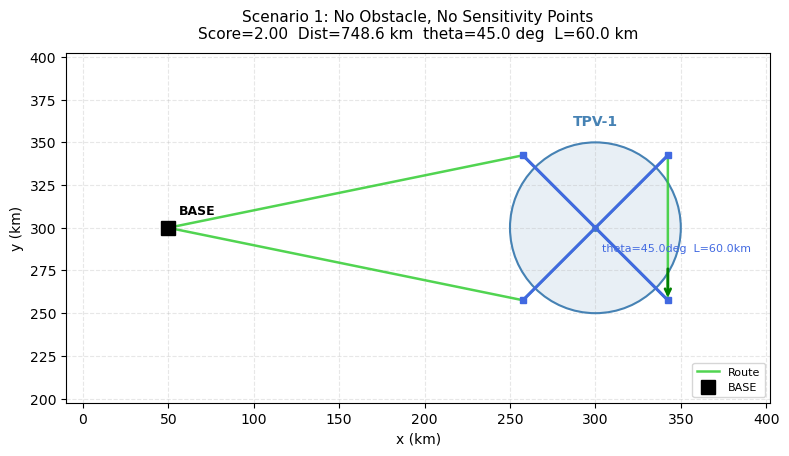

Figure saved.


In [8]:
# ─── Scenario 1 Plot ─────────────────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(8, 6))
draw_scenario(
    ax1, [cell_s1], BASE, solution=sol_s1,
    title='Scenario 1: No Obstacle, No Sensitivity Points'
)
plt.tight_layout()
plt.savefig(
    '/home/yuanpei_cao/aerial-met-survey-optimizer/figures/unit_test_s1.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print('Figure saved.')

In [9]:
# ─── Scenario 1 Global Optimality Proof ──────────────────────────────────────

prove_global_optimality(
    cell_s1, BASE, BUDGET_S1, THETA_GRID, N_L_LEVELS, sol_s1
)


GLOBAL OPTIMALITY PROOF — exhaustive (theta, L) enumeration
theta (deg)   L (km)     Status         Dist (km)   
--------------------------------------------------------------------
45.0          60.00      valid          748.58        <-- GLOBAL OPTIMUM
135.0         60.00      valid          748.58      
30.0          60.00      valid          751.20      
120.0         60.00      valid          751.20      
150.0         60.00      valid          751.20      
75.0          60.00      valid          759.05      
105.0         60.00      valid          759.05      
165.0         60.00      valid          759.05      
0.0           60.00      valid          771.95      
90.0          60.00      valid          771.95      
15.0          60.00      valid          789.30      
45.0          72.00      valid          800.81      
135.0         72.00      valid          800.81      
30.0          72.00      valid          803.79      
120.0         72.00      valid          803.79      
  

---
## Scenario 2 — Obstacle Between BASE and Circle

**Setup (same cell as S1):**
- Obstacle: rectangle at x ∈ [140, 210], y ∈ [270, 330]  
  This sits **directly in the straight-line corridor between BASE (50, 300) and the cell (300, 300)**.

**Effects of the obstacle:**
1. **Transit blocked** — the direct path BASE → cell entry is blocked; the route must detour around the obstacle.
2. **Some cross legs blocked** — for θ = 0°, the west arm of the cross extends toward BASE and passes through the
   obstacle when L is large enough (west arm endpoint x = 300 − L reaches x < 210 for L > 90 km).
   All smaller-L configs with θ = 0° still have an unblocked cross but a detoured transit.

**Expected:** optimizer avoids blocked (θ, L) pairs; the green route clearly detours around the red obstacle.
**Proof:** exhaustive table confirms the selected (θ, L) is globally optimal.

In [10]:
# ─── Scenario 2 Setup ────────────────────────────────────────────────────────
#
# Obstacle geometry:
#   x in [140, 210], y in [270, 330]
#   Centroid ≈ (175, 300) — lies on the direct line BASE(50,300)->cell(300,300).
#   Width (x): 70 km   Height (y): 60 km

obstacle_s2 = [
    [140.0, 270.0],
    [210.0, 270.0],
    [210.0, 330.0],
    [140.0, 330.0],
]

cell_s2 = CircularSupercell(
    center=np.array([300.0, 300.0]),
    radius=50.0,
    L_max=120.0,
    weight=2.0,
    name='TPV-1',
    sensitivity_points=[],
    obstacle=obstacle_s2,
)

# Slightly larger budget to accommodate transit detour
BUDGET_S2 = 1250.0

print(f'Obstacle vertices (CCW): {[list(v) for v in cell_s2.obstacle]}')
print(f'Budget: {BUDGET_S2} km')
print()

# Show which (theta, L) configs are blocked by the obstacle
L_grid_s2 = np.linspace(cell_s2.radius + 10, cell_s2.L_max, N_L_LEVELS)
print('Cross-pattern blocking status (True = cross arm hits obstacle):')
print(f'{"theta (deg)":<14}', end='')
for L in L_grid_s2:
    print(f'{"L="+str(round(L,1)):>12}', end='')
print()
for theta in THETA_GRID:
    print(f'{np.degrees(theta):<14.1f}', end='')
    for L in L_grid_s2:
        b = cell_s2.cross_blocked(theta, L)
        print(f'{str(b):>12}', end='')
    print()

Obstacle vertices (CCW): [[140.0, 270.0], [210.0, 270.0], [210.0, 330.0], [140.0, 330.0]]
Budget: 1250.0 km

Cross-pattern blocking status (True = cross arm hits obstacle):
theta (deg)         L=60.0      L=72.0      L=84.0      L=96.0     L=108.0     L=120.0
0.0                  False       False       False        True        True        True
15.0                 False       False       False        True        True        True
30.0                 False       False       False       False       False       False
45.0                 False       False       False       False       False       False
60.0                 False       False       False       False       False       False
75.0                 False       False       False        True        True        True
90.0                 False       False       False        True        True        True
105.0                False       False       False        True        True        True
120.0                False       False      

In [11]:
# ─── Scenario 2 Optimize ─────────────────────────────────────────────────────

print('Running optimizer for Scenario 2...')
sol_s2 = optimize([cell_s2], BASE, BUDGET_S2, THETA_GRID, N_L_LEVELS)
print(f'  Score      : {sol_s2["score"]:.2f}')
print(f'  Dist       : {sol_s2["dist"]:.2f} km')
print(f'  Theta      : {round(np.degrees(sol_s2["thetas"][0]), 1)} deg')
print(f'  L          : {round(sol_s2["Ls"][0], 2)} km')
print(f'  Cross blocked? {cell_s2.cross_blocked(sol_s2["thetas"][0], sol_s2["Ls"][0])}')

Running optimizer for Scenario 2...


  Optimizer: 72 configs evaluated.
  Score      : 2.00
  Dist       : 751.05 km
  Theta      : 45.0 deg
  L          : 60.0 km
  Cross blocked? False


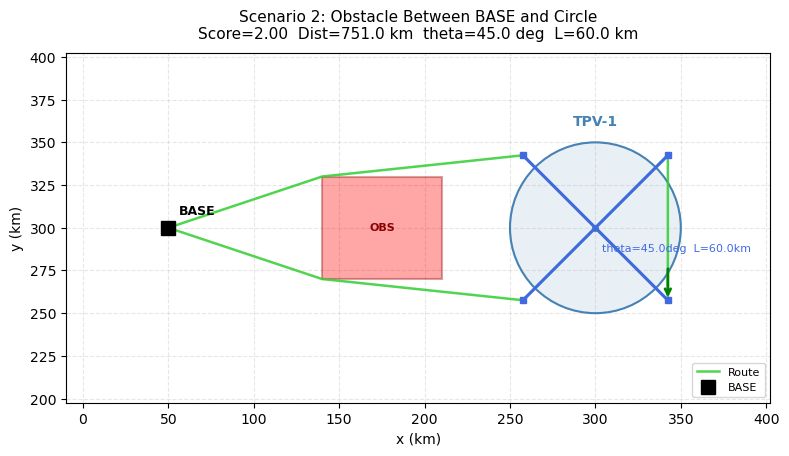

Figure saved.
Visual check: the green route should visibly detour around the red obstacle.


In [12]:
# ─── Scenario 2 Plot ─────────────────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(8, 6))
draw_scenario(
    ax2, [cell_s2], BASE, solution=sol_s2,
    title='Scenario 2: Obstacle Between BASE and Circle'
)
plt.tight_layout()
plt.savefig(
    '/home/yuanpei_cao/aerial-met-survey-optimizer/figures/unit_test_s2.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print('Figure saved.')
print('Visual check: the green route should visibly detour around the red obstacle.')

In [13]:
# ─── Scenario 2 Global Optimality Proof ──────────────────────────────────────

prove_global_optimality(
    cell_s2, BASE, BUDGET_S2, THETA_GRID, N_L_LEVELS, sol_s2
)


GLOBAL OPTIMALITY PROOF — exhaustive (theta, L) enumeration
theta (deg)   L (km)     Status         Dist (km)   
--------------------------------------------------------------------
45.0          60.00      valid          751.05        <-- GLOBAL OPTIMUM
135.0         60.00      valid          751.05      
30.0          60.00      valid          754.47      
120.0         60.00      valid          754.47      
150.0         60.00      valid          754.47      
105.0         60.00      valid          766.90      
75.0          60.00      valid          766.90      
165.0         60.00      valid          766.90      
0.0           60.00      valid          789.80      
90.0          60.00      valid          789.80      
15.0          60.00      valid          797.49      
45.0          72.00      valid          801.71      
135.0         72.00      valid          801.71      
30.0          72.00      valid          805.54      
120.0         72.00      valid          805.54      
  

---
## Scenario 3 — Obstacle + Sensitivity Points

**Setup (same cell + same obstacle as S2, plus 2 sensitivity points):**

| Point | Location | Angle from center | Purpose |
|---|---|---|---|
| S1 | (300, 242) | 270° (south) | Forces a southward detour after the cross |
| S2 | (358, 343) | 50° (NE) | Forces a northeast detour |

Both points are outside the obstacle and the cell radius.  The aircraft must visit them
**after** the cross scan before returning to BASE.

**Expected:** route distance > S2 because of the sensitivity-point detours; both points visibly
lie on the green route.

**Proof:** exhaustive table over (θ, L) with full sensitivity routing confirms global optimality.

In [14]:
# ─── Scenario 3 Setup ────────────────────────────────────────────────────────

center_s3 = np.array([300.0, 300.0])
radius_s3 = 50.0

# S1: due south of center, just outside the circle
sp1 = center_s3 + (radius_s3 + 8) * uvec(radians(270))   # (300, 242)
# S2: NE of center, just outside the circle
sp2 = center_s3 + (radius_s3 + 8) * uvec(radians(50))    # (~308, 351)

obstacle_s3 = [
    [140.0, 270.0],
    [210.0, 270.0],
    [210.0, 330.0],
    [140.0, 330.0],
]

cell_s3 = CircularSupercell(
    center=center_s3,
    radius=radius_s3,
    L_max=120.0,
    weight=2.0,
    name='TPV-1',
    sensitivity_points=[sp1, sp2],
    obstacle=obstacle_s3,
)

# Larger budget to accommodate sensitivity-point detours
BUDGET_S3 = 1400.0

print(f'Sensitivity points:')
for j, sp in enumerate(cell_s3.sensitivity_points):
    print(f'  S{j+1} = {sp.round(2)}')
print(f'Budget: {BUDGET_S3} km')

Sensitivity points:
  S1 = [300. 242.]
  S2 = [337.28 344.43]
Budget: 1400.0 km


In [15]:
# ─── Scenario 3 Optimize ─────────────────────────────────────────────────────

print('Running optimizer for Scenario 3...')
sol_s3 = optimize([cell_s3], BASE, BUDGET_S3, THETA_GRID, N_L_LEVELS)
print(f'  Score      : {sol_s3["score"]:.2f}')
print(f'  Dist       : {sol_s3["dist"]:.2f} km')
print(f'  Theta      : {round(np.degrees(sol_s3["thetas"][0]), 1)} deg')
print(f'  L          : {round(sol_s3["Ls"][0], 2)} km')
print(f'  Cross blocked? {cell_s3.cross_blocked(sol_s3["thetas"][0], sol_s3["Ls"][0])}')

Running optimizer for Scenario 3...


  Optimizer: 72 configs evaluated.
  Score      : 2.00
  Dist       : 796.90 km
  Theta      : 0.0 deg
  L          : 60.0 km
  Cross blocked? False


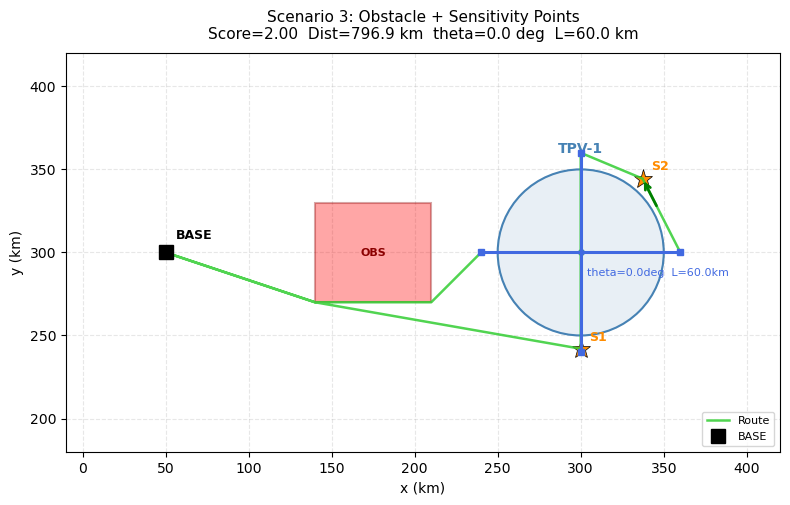

Figure saved.
Visual check: route should detour around red obstacle AND pass through both orange stars.


In [16]:
# ─── Scenario 3 Plot ─────────────────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(8, 7))
draw_scenario(
    ax3, [cell_s3], BASE, solution=sol_s3,
    title='Scenario 3: Obstacle + Sensitivity Points'
)
plt.tight_layout()
plt.savefig(
    '/home/yuanpei_cao/aerial-met-survey-optimizer/figures/unit_test_s3.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print('Figure saved.')
print('Visual check: route should detour around red obstacle AND pass through both orange stars.')

In [17]:
# ─── Scenario 3 Global Optimality Proof ──────────────────────────────────────

prove_global_optimality(
    cell_s3, BASE, BUDGET_S3, THETA_GRID, N_L_LEVELS, sol_s3
)


GLOBAL OPTIMALITY PROOF — exhaustive (theta, L) enumeration
theta (deg)   L (km)     Status         Dist (km)   
--------------------------------------------------------------------
0.0           60.00      valid          796.90        <-- GLOBAL OPTIMUM
90.0          60.00      valid          796.90      
75.0          60.00      valid          801.90      
165.0         60.00      valid          801.90      
15.0          60.00      valid          802.91      
105.0         60.00      valid          802.91      
30.0          60.00      valid          819.10      
120.0         60.00      valid          819.10      
60.0          60.00      valid          835.69      
150.0         60.00      valid          835.69      
45.0          60.00      valid          841.68      
135.0         60.00      valid          841.68      
75.0          72.00      valid          857.61      
165.0         72.00      valid          857.61      
15.0          72.00      valid          858.10      
  

---
## Final Comparison

All three scenarios visit the same cell (score = 2.0).  The route distance increases as
the model complexity grows:

- **S1 < S2**: obstacle forces a transit detour and may block shorter cross legs
- **S2 < S3**: sensitivity points add mandatory post-scan waypoints

In [18]:
# ─── Final Comparison ────────────────────────────────────────────────────────

print('=' * 65)
print('ALL SCENARIOS COMPARISON')
print('=' * 65)
print(f'{"Scenario":<38} {"Score":<8} {"Dist (km)":<12} {"Budget":<8}')
print('-' * 65)

rows = [
    ('S1: No obstacle, no sens pts',     sol_s1, BUDGET_S1),
    ('S2: Obstacle between BASE & cell', sol_s2, BUDGET_S2),
    ('S3: Obstacle + sensitivity pts',   sol_s3, BUDGET_S3),
]
for name, sol, budget in rows:
    print(f'{name:<38} {sol["score"]:<8.2f} {sol["dist"]:<12.2f} {budget:<8.0f}')

print('=' * 65)
print()

# Sanity assertions
assert sol_s1['score'] == 2.0, 'S1 must visit the cell'
assert sol_s2['score'] == 2.0, 'S2 must visit the cell'
assert sol_s3['score'] == 2.0, 'S3 must visit the cell'
assert sol_s2['dist'] > sol_s1['dist'], 'S2 dist must exceed S1 (obstacle detour)'
assert sol_s3['dist'] > sol_s2['dist'], 'S3 dist must exceed S2 (sensitivity pts)'
assert not cell_s2.cross_blocked(sol_s2['thetas'][0], sol_s2['Ls'][0]), \
    'S2 chosen theta/L must not be blocked'
assert not cell_s3.cross_blocked(sol_s3['thetas'][0], sol_s3['Ls'][0]), \
    'S3 chosen theta/L must not be blocked'

print('All sanity assertions passed.')
print()
print(f'Distance overhead vs S1:')
print(f'  Obstacle adds       : {sol_s2["dist"] - sol_s1["dist"]:+.1f} km')
print(f'  Sens. pts add       : {sol_s3["dist"] - sol_s2["dist"]:+.1f} km (on top of obstacle)')

ALL SCENARIOS COMPARISON
Scenario                               Score    Dist (km)    Budget  
-----------------------------------------------------------------
S1: No obstacle, no sens pts           2.00     748.58       1100    
S2: Obstacle between BASE & cell       2.00     751.05       1250    
S3: Obstacle + sensitivity pts         2.00     796.90       1400    

All sanity assertions passed.

Distance overhead vs S1:
  Obstacle adds       : +2.5 km
  Sens. pts add       : +45.9 km (on top of obstacle)
